In [1]:
#THIS IS FOR DECONTAM  BUILDING ALPHA DIVERSITY METRICS FOR PLOTTING
#raw = pd.read_csv("/content/zotutab_decontam_Final.csv", header=None)
#D_alpha_df = pd.DataFrame(records)
#D_alpha_df.to_csv("alpha_diversity_DECONTAM.csv", index=False)

import pandas as pd
import numpy as np

# ============================
# LOAD WITH NO HEADER
# ============================
raw = pd.read_csv("/content/zotutab_decontam_Final.csv", header=None)

# Row 0 = anatomy
anatomy_row = raw.iloc[0]

# Row 1 = actual column names
header = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header

# Reset index cleanly
df.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY COLUMNS
# ============================
zotu_col = df.columns[0]
taxonomy_cols = df.columns[-7:]
sample_cols = df.columns[1:-7]

# ============================
# BUILD ANATOMY MAP
# ============================
anatomy_map = {
    sample_cols[i]: anatomy_row[i+1]
    for i in range(len(sample_cols))
}

# ============================
# NUMERIC CONVERSION
# ============================
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================
# HELPER FUNCTIONS
# ============================
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0,0,0,0
    N = counts.sum()
    p = counts / N
    shannon = -np.sum(p * np.log(p))
    simpson = 1 - np.sum(p**2)
    richness = len(counts)
    evenness = shannon/np.log(richness) if richness>1 else 0
    return shannon, simpson, evenness, richness

def get_field(sample):
    if sample.startswith("MF"): return "Mesquite Flat"
    if sample.startswith("ED"): return "Eureka"
    if sample.startswith("IX"): return "Ibex"
    return "Other"

def simplify_anatomy(a):
    if pd.isna(a): return "Unknown"
    a = str(a).lower()
    if "stoss" in a: return "Stoss"
    if "lee" in a: return "Lee"
    if "interdune" in a: return "Interdune"
    return "Other"

# ============================
# ALPHA DIVERSITY
# ============================
records = []

for sample in sample_cols:
    counts = df[sample].values.astype(float)
    shannon, simpson, evenness, richness = compute_alpha(counts)

    records.append({
        "Sample": sample,
        "Field": get_field(sample),
        "Anatomy": simplify_anatomy(anatomy_map[sample]),
        "Shannon": shannon,
        "Simpson": simpson,
        "Evenness": evenness,
        "Richness": richness
    })

D_alpha_df = pd.DataFrame(records)
D_alpha_df.to_csv("alpha_diversity_DECONTAM.csv", index=False)
print("Alpha diversity saved")


Alpha diversity saved


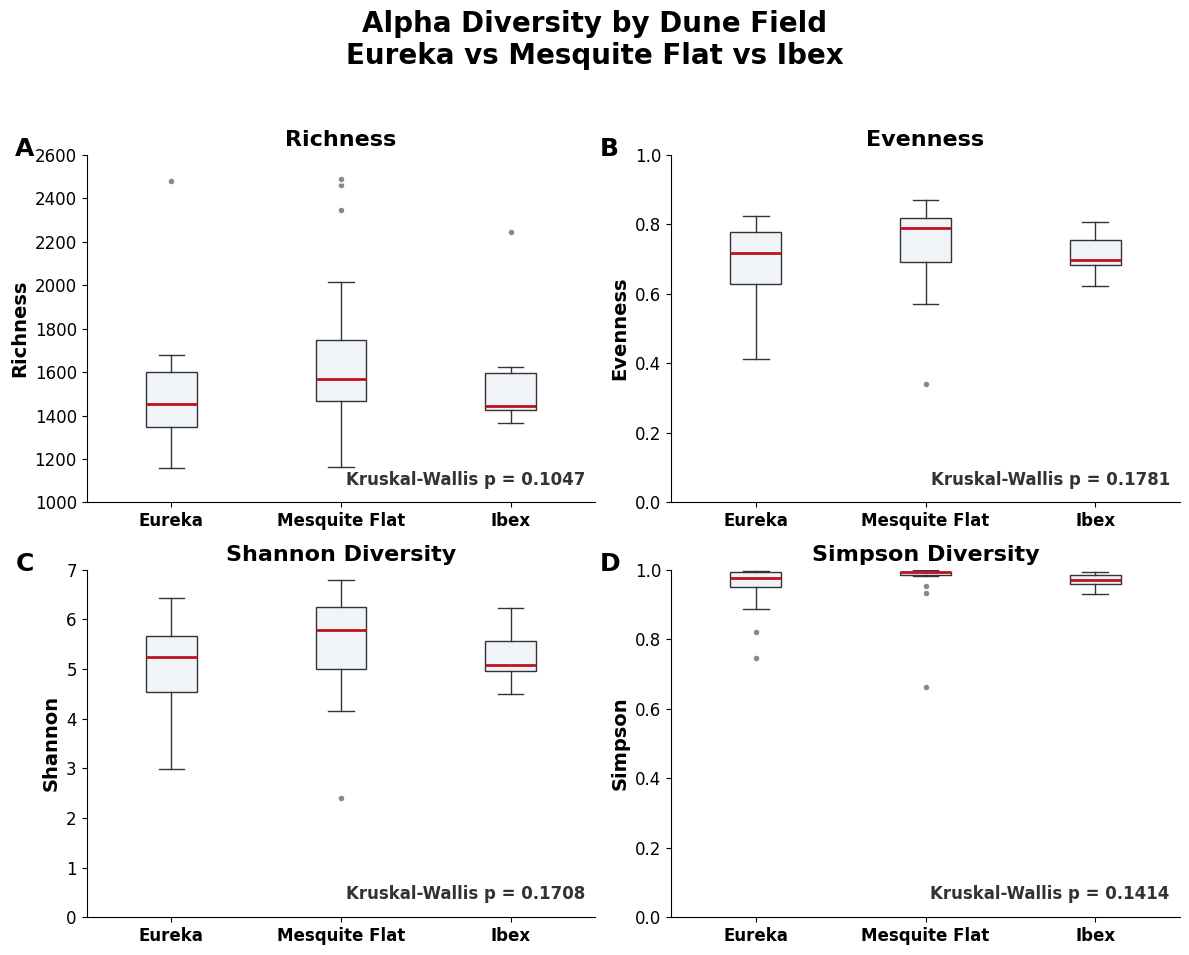

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================
# GROUPS
# ============================
x = ["Eureka", "Mesquite Flat", "Ibex"]

y1 = [D_alpha_df[D_alpha_df["Field"] == f]["Shannon"]  for f in x]
y2 = [D_alpha_df[D_alpha_df["Field"] == f]["Simpson"]  for f in x]
y3 = [D_alpha_df[D_alpha_df["Field"] == f]["Evenness"] for f in x]
y4 = [D_alpha_df[D_alpha_df["Field"] == f]["Richness"] for f in x]

# ============================
# KRUSKAL-WALLIS TESTS
# ============================
p_shannon = kruskal(*y1).pvalue
p_simpson = kruskal(*y2).pvalue
p_even    = kruskal(*y3).pvalue
p_rich    = kruskal(*y4).pvalue

# ============================
# FIGURE
# order: Richness (A), Evenness (B), Shannon (C), Simpson (D)
# ============================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Alpha Diversity by Dune Field\nEureka vs Mesquite Flat vs Ibex",
    fontsize=20, fontweight="bold"
)

def box(ax, data, title, ylabel, p, panel_label, ylim=None):

    bp = ax.boxplot(
        data,
        tick_labels=x,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color="#c1121f", linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=5, linestyle="none",
                        markeredgecolor="white")
    )

    # panel label A/B/C/D
    ax.text(-0.14, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.text(
        0.98, 0.04,
        f"Kruskal-Wallis p = {p:.4f}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        color="#333333"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================
# DRAW PANELS
# A = Richness, B = Evenness, C = Shannon, D = Simpson
# ============================
box(axs[0,0], y4, "Richness",         "Richness", p_rich,    "A", (1000, 2600))
box(axs[0,1], y3, "Evenness",         "Evenness", p_even,    "B", (0, 1))
box(axs[1,0], y1, "Shannon Diversity","Shannon",  p_shannon, "C", (0, 7))
box(axs[1,1], y2, "Simpson Diversity","Simpson",  p_simpson, "D", (0, 1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [10]:
!pip install scikit-posthocs

In [11]:
import pandas as pd
import scikit_posthocs as sp
from scipy.stats import kruskal

# ============================
# LOAD FILE
# ============================
df = pd.read_csv("/content/alpha_diversity_DECONTAM.csv")

# ============================
# KRUSKAL-WALLIS FIRST
# ============================
metrics = ['Shannon', 'Simpson', 'Evenness', 'Richness']

print("=" * 55)
print("KRUSKAL-WALLIS RESULTS")
print("=" * 55)

significant = []

for metric in metrics:
    groups = [df[df['Field'] == f][metric] for f in df['Field'].unique()]
    stat, p = kruskal(*groups)
    sig = "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{metric:<12}: H = {stat:.3f}  p = {p:.4f}  {sig}")
    if p < 0.05:
        significant.append(metric)

# ============================
# DUNN POST-HOC (significant metrics only)
# ============================
print("\n" + "=" * 55)
print("DUNN POST-HOC TEST (FDR corrected, significant metrics only)")
print("=" * 55)

for metric in significant:
    print(f"\n--- {metric} ---")
    result = sp.posthoc_dunn(
        df,
        val_col=metric,
        group_col='Field',
         p_adjust='fdr_bh'
    )
    print(result.round(4))

    print(f"\nSignificant pairs (p < 0.05):")
    printed = set()
    for col in result.columns:
        for row in result.index:
            pair = tuple(sorted([row, col]))
            if row != col and result.loc[row, col] < 0.05 and pair not in printed:
                print(f"  {row} vs {col}: p = {result.loc[row, col]:.4f}")
                printed.add(pair)

KRUSKAL-WALLIS RESULTS
Shannon     : H = 3.535  p = 0.1708  ns
Simpson     : H = 3.913  p = 0.1414  ns
Evenness    : H = 3.451  p = 0.1781  ns
Richness    : H = 4.513  p = 0.1047  ns

DUNN POST-HOC TEST (FDR corrected, significant metrics only)


In [14]:
# ---------- DOMAIN-SPECIFIC ALPHA ----------

import pandas as pd
import numpy as np

path = "/content/zotutab_decontam_Final.csv"

# ---------- LOAD RAW ----------
raw = pd.read_csv(path, header=None)

# Row 1 = real header, rows 2+ = data
df = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

# ---------- COLUMN POSITIONS ----------
zotu_col = df.columns[0]
taxonomy_cols = df.columns[-7:]
sample_cols = df.columns[1:-7]

# ---------- NUMERIC COUNTS ----------
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ---------- HELPER ----------
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0,0,0,0
    N = counts.sum()
    p = counts / N
    shannon = -np.sum(p * np.log(p))
    simpson = 1 - np.sum(p**2)
    richness = len(counts)
    evenness = shannon/np.log(richness) if richness>1 else 0
    return shannon, simpson, evenness, richness

# ---------- DOMAIN-SPECIFIC ALPHA ----------
records = []

for domain in df["Domain"].unique():
    sub = df[df["Domain"] == domain]

    for sample in sample_cols:
        counts = sub[sample].values.astype(float)
        shannon, simpson, evenness, richness = compute_alpha(counts)

        records.append({
            "Domain": domain,
            "Sample": sample,
            "Shannon": shannon,
            "Simpson": simpson,
            "Evenness": evenness,
            "Richness": richness
        })

D_domain_alpha_df = pd.DataFrame(records)

print("Built D_domain_alpha_df from:", path)
print(D_domain_alpha_df.head())


Built D_domain_alpha_df from: /content/zotutab_decontam_Final.csv
     Domain Sample   Shannon   Simpson  Evenness  Richness
0  bacteria  MF.4B  4.140565  0.937652  0.572993      1375
1  bacteria  MF.5B  5.583101  0.987557  0.759685      1555
2  bacteria  MF.6B  6.345774  0.994622  0.839033      1926
3  bacteria  MF.7B  6.315238  0.993521  0.816959      2276
4  bacteria  MF.8B  6.758974  0.997375  0.869620      2374


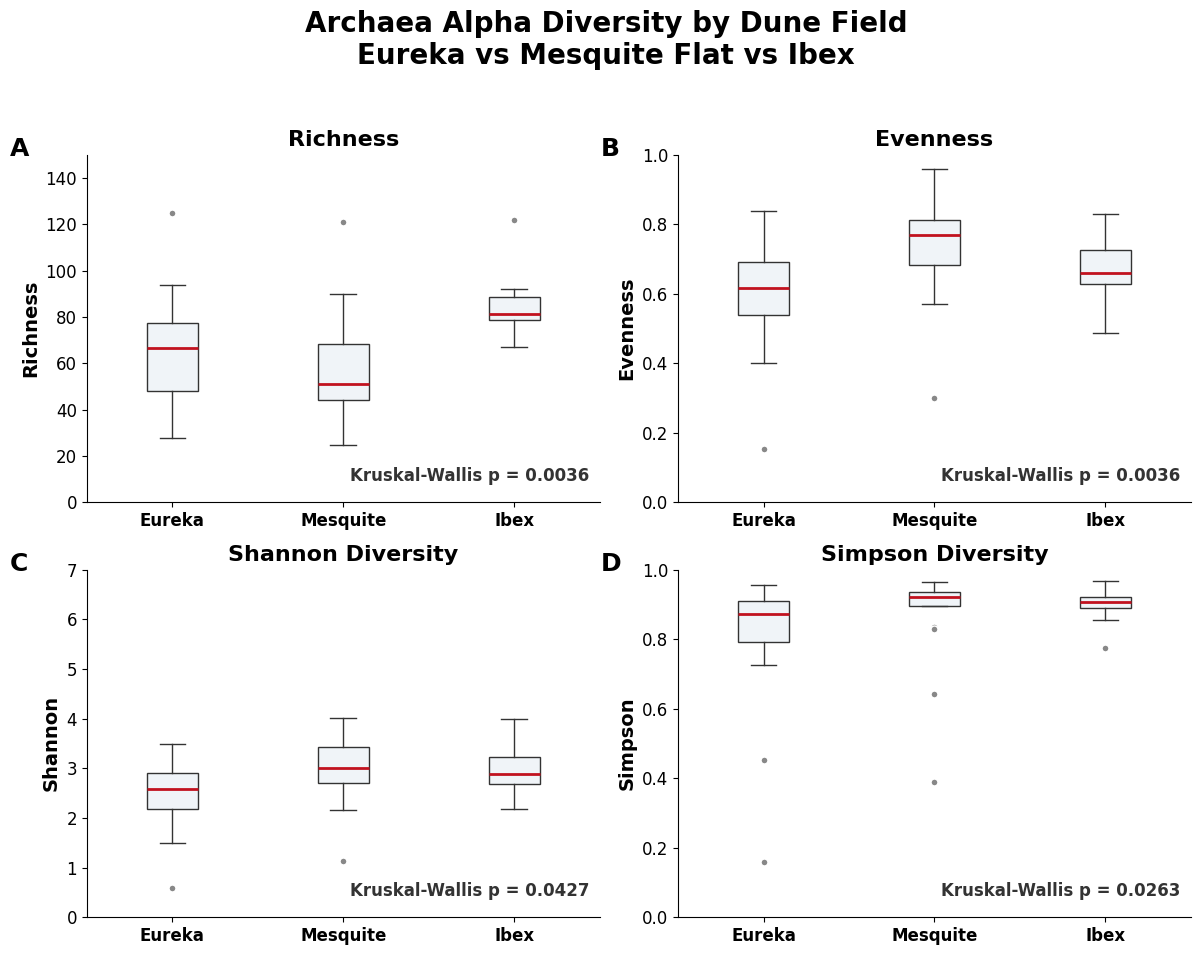

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================
# FILTER TO ARCHAEA
# ============================
archaea_df = df[df["Domain"].str.lower() == "archaea"]

# ============================
# HELPER FUNCTIONS
# ============================
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p**2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

def get_field(sample):
    if sample.startswith("MF"): return "Mesquite"
    if sample.startswith("ED"): return "Eureka"
    if sample.startswith("IX"): return "Ibex"
    return "Other"

# ============================
# BUILD ALPHA TABLE
# ============================
records = []
for sample in sample_cols:
    counts = archaea_df[sample].values.astype(float)
    shannon, simpson, evenness, richness = compute_alpha(counts)
    records.append({
        "Sample":   sample,
        "Field":    get_field(sample),
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
        "Richness": richness
    })

alpha_archaea = pd.DataFrame(records)

# ============================
# SAFE KRUSKAL-WALLIS
# ============================
def safe_kruskal(groups_list):
    valid = [g for g in groups_list if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

# ============================
# GROUPS
# ============================
x  = ["Eureka", "Mesquite", "Ibex"]

y1 = [alpha_archaea[alpha_archaea["Field"] == f]["Shannon"]  for f in x]
y2 = [alpha_archaea[alpha_archaea["Field"] == f]["Simpson"]  for f in x]
y3 = [alpha_archaea[alpha_archaea["Field"] == f]["Evenness"] for f in x]
y4 = [alpha_archaea[alpha_archaea["Field"] == f]["Richness"] for f in x]

p_shannon = safe_kruskal(y1)
p_simpson = safe_kruskal(y2)
p_even    = safe_kruskal(y3)
p_rich    = safe_kruskal(y4)

# ============================
# FIGURE
# order: Richness (A), Evenness (B), Shannon (C), Simpson (D)
# ============================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Archaea Alpha Diversity by Dune Field\n"
    "Eureka vs Mesquite Flat vs Ibex",
    fontsize=20, fontweight="bold"
)

def box(ax, data, title, ylabel, p, panel_label, ylim=None):

    ax.boxplot(
        data,
        tick_labels=x,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color="#c1121f", linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=5, linestyle="none",
                        markeredgecolor="white")
    )

    #panel label
    ax.text(-0.15, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    p_text = f"{p:.4f}" if not np.isnan(p) else "N/A"
    ax.text(
        0.98, 0.05,
        f"Kruskal-Wallis p = {p_text}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        color="#333333"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================
# DRAW PANELS
# A = Richness, B = Evenness, C = Shannon, D = Simpson
# ============================
box(axs[0,0], y4, "Richness",         "Richness", p_rich,    "A", (0, 150))
box(axs[0,1], y3, "Evenness",         "Evenness", p_even,    "B", (0, 1))
box(axs[1,0], y1, "Shannon Diversity","Shannon",  p_shannon, "C", (0, 7))
box(axs[1,1], y2, "Simpson Diversity","Simpson",  p_simpson, "D", (0, 1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


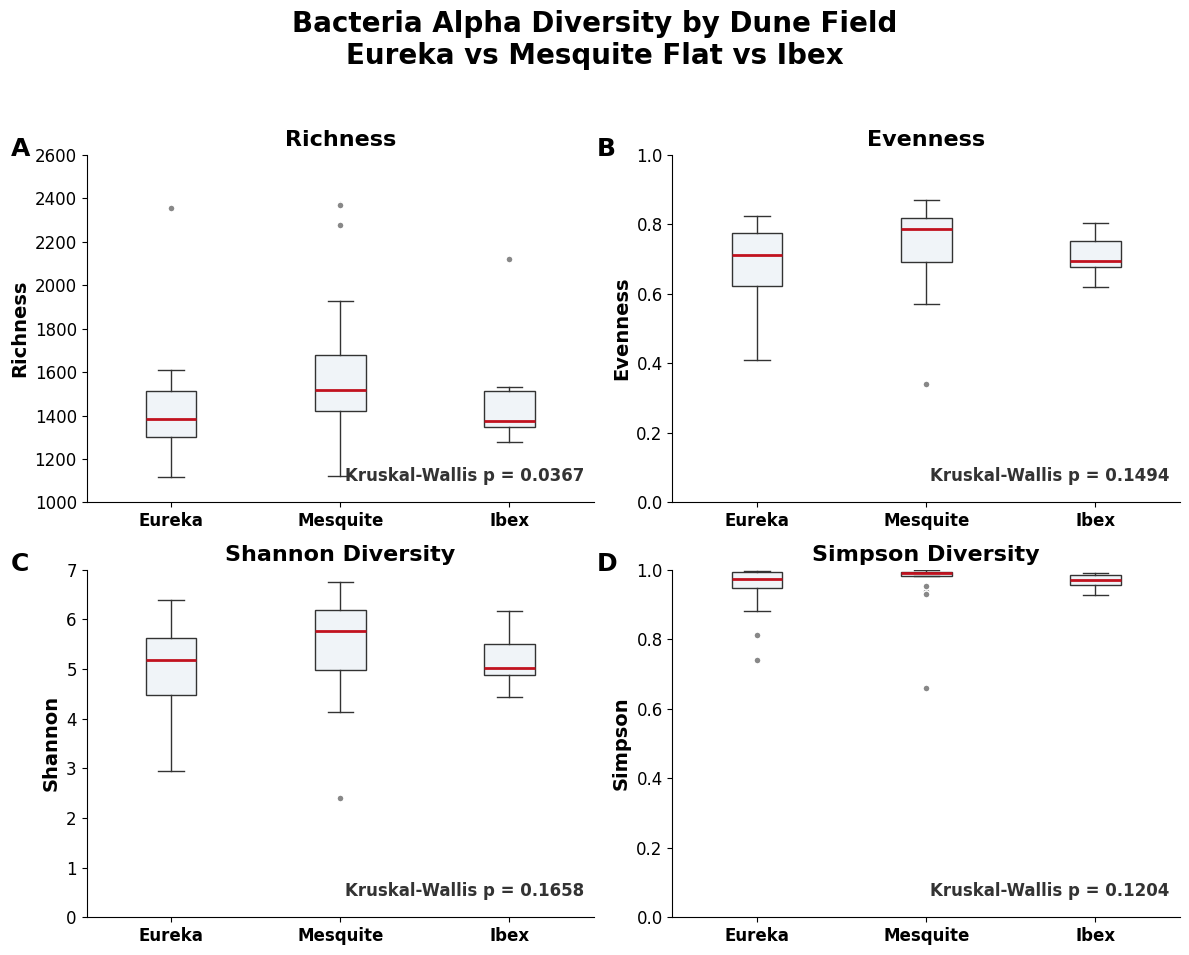

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================
# FILTER TO BACTERIA
# ============================
alpha_bact = D_domain_alpha_df[
    D_domain_alpha_df["Domain"].str.lower() == "bacteria"].copy()

alpha_bact["Field"] = alpha_bact["Sample"].apply(lambda s:
    "Mesquite" if s.startswith("MF") else
    "Eureka"   if s.startswith("ED") else
    "Ibex"     if s.startswith("IX") else "Other"
)

# ============================
# SAFE KRUSKAL-WALLIS
# ============================
def safe_kruskal(groups_list):
    valid = [g for g in groups_list if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

# ============================
# GROUPS
# ============================
x  = ["Eureka", "Mesquite", "Ibex"]

y1 = [alpha_bact[alpha_bact["Field"] == f]["Shannon"]  for f in x]
y2 = [alpha_bact[alpha_bact["Field"] == f]["Simpson"]  for f in x]
y3 = [alpha_bact[alpha_bact["Field"] == f]["Evenness"] for f in x]
y4 = [alpha_bact[alpha_bact["Field"] == f]["Richness"] for f in x]

p_shannon = safe_kruskal(y1)
p_simpson = safe_kruskal(y2)
p_even    = safe_kruskal(y3)
p_rich    = safe_kruskal(y4)

# ============================
# FIGURE
# A = Richness, B = Evenness, C = Shannon, D = Simpson
# ============================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Bacteria Alpha Diversity by Dune Field\n"
    "Eureka vs Mesquite Flat vs Ibex",
    fontsize=20, fontweight="bold"
)

def box(ax, data, title, ylabel, p, panel_label, ylim=None):

    ax.boxplot(
        data,
        tick_labels=x,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color="#c1121f", linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=5, linestyle="none",
                        markeredgecolor="white")
    )

    # panel label
    ax.text(-0.15, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    p_text = f"{p:.4f}" if not np.isnan(p) else "N/A"
    ax.text(
        0.98, 0.05,
        f"Kruskal-Wallis p = {p_text}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        color="#333333"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================
# DRAW PANELS
# ============================
box(axs[0,0], y4, "Richness",         "Richness", p_rich,    "A", (1000, 2600))
box(axs[0,1], y3, "Evenness",         "Evenness", p_even,    "B", (0, 1))
box(axs[1,0], y1, "Shannon Diversity","Shannon",  p_shannon, "C", (0, 7))
box(axs[1,1], y2, "Simpson Diversity","Simpson",  p_simpson, "D", (0, 1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [28]:
!pip install scikit-bio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 80.3 MB/s eta 0:00:00


File structure: anatomy row = True
Prokaryotic ZOTUs: 5892  |  Samples: 52
Shared samples: 52

Bray-Curtis: 0.000 - 0.936
[Bray-Curtis] PCo1: 14.5%  PCo2: 9.2%

Running PERMANOVA + PERMDISP (999 permutations)...

PERMANOVA RESULTS — Bray-Curtis
  Field          R2=14.8%  p=0.001 **
  Morphology     R2=13.5%  p=0.002 **  [PERMDISP p=0.001 *]
  GrainSize      R2=14.5%  p=0.001 **
  Moisture       R2=7.6%  p=0.001 **

BETADISPER — per-group dispersion where significant

Bray-Curtis | Morphology:
                n  mean_dist      sd
Interdune    12.0     0.3868  0.0113
Stoss        15.0     0.3568  0.0112
Lee          19.0     0.3527  0.0161
Stoss, Star   4.0     0.2196  0.0038


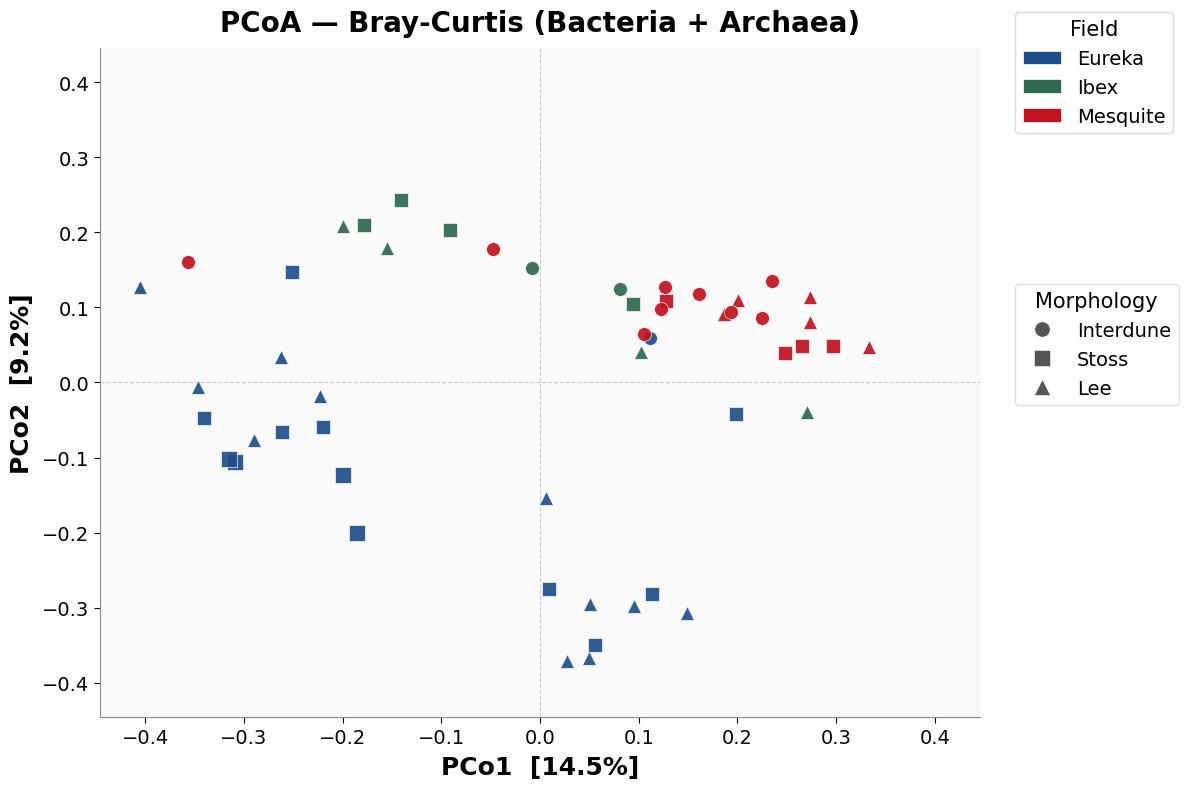

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ============================
# LOAD DATA
# ============================
def load_otu(path):
    raw = pd.read_csv(path, header=None)

    # detect file structure
    first_val = str(raw.iloc[0, 0]).strip().upper()
    if first_val == "ANATOMY":
        header_row = 1
        data_start = 2
    else:
        header_row = 0
        data_start = 1

    df = raw.iloc[data_start:].copy()
    df.columns = raw.iloc[header_row].values
    df.reset_index(drop=True, inplace=True)

    n_tax     = 7
    tax_cols  = list(df.columns[-n_tax:])
    samp_cols = [c for c in df.columns[1:]
                 if c not in tax_cols
                 and "Blank" not in str(c)]

    for col in samp_cols:
        df[col] = pd.to_numeric(df[col],
                                errors="coerce").fillna(0)

    domain_col = tax_cols[0]
    df[domain_col] = (df[domain_col].astype(str)
                      .str.strip().str.lower())
    micro = df[df[domain_col].isin(
        ["bacteria", "archaea"])].copy()

    print(f"File structure: anatomy row = {first_val == 'ANATOMY'}")
    print(f"Prokaryotic ZOTUs: {len(micro)}  "
          f"|  Samples: {len(samp_cols)}")

    return pd.DataFrame(
        micro[samp_cols].values.T,
        index=samp_cols,
        columns=micro[micro.columns[0]]
    )

otu  = load_otu("/content/zotutab_decontam_Final.csv")
meta = pd.read_csv("/content/PERM_metadata.csv").rename(
           columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

shared   = sorted(set(otu.index) & set(meta.index))
otu      = otu.loc[shared]
meta_aln = meta.loc[shared].copy()

print(f"Shared samples: {len(shared)}")

cont_vars = ["GrainSize", "Moisture"]
for c in cont_vars:
    meta_aln[c] = pd.to_numeric(meta_aln[c], errors="coerce")
meta_aln[cont_vars] = meta_aln[cont_vars].fillna(
    meta_aln[cont_vars].median())
meta_aln["Morphology"] = meta_aln["Morphology"].str.strip()

cat_vars = ["Field", "Morphology"]
all_vars = cat_vars + cont_vars

# ============================
# BRAY-CURTIS ONLY
# ============================
arr    = otu.values.astype(float)
ids    = list(otu.index)
bc_arr = squareform(pdist(arr, metric="braycurtis"))
dm_bc  = DistanceMatrix(bc_arr, ids=ids)

print(f"\nBray-Curtis: {bc_arr.min():.3f} - {bc_arr.max():.3f}")

# ============================
# PCoA
# ============================
def pcoa(D):
    D2   = D ** 2
    B    = -0.5 * (D2 - D2.mean(1, keepdims=True)
                      - D2.mean(0, keepdims=True) + D2.mean())
    ev, evec = np.linalg.eigh(B)
    idx  = np.argsort(ev)[::-1]
    ev   = ev[idx]
    evec = evec[:, idx]
    pos  = ev > 0
    return evec[:, pos] * np.sqrt(ev[pos]), ev[pos] / ev[pos].sum() * 100

coords_bc, var_bc = pcoa(bc_arr)
print(f"[Bray-Curtis] PCo1: {var_bc[0]:.1f}%  PCo2: {var_bc[1]:.1f}%")

# ============================
# PERMANOVA HELPERS
# ============================
def get_pval(r):
    for k in ["p-value", "p_value", "pvalue"]:
        if k in r.index:
            return r[k]
    return np.nan

def manual_r2(d, groups):
    g    = np.array(groups)
    n    = len(g)
    ss_t = np.sum(d ** 2) / n
    ss_w = sum(
        np.sum(d[np.ix_(np.where(g == x)[0],
                         np.where(g == x)[0])] ** 2) /
        len(np.where(g == x)[0])
        for x in np.unique(g)
        if len(np.where(g == x)[0]) > 1
    )
    return (ss_t - ss_w) / ss_t if ss_t > 0 else np.nan

def sig_str(p):
    try:
        p = float(p)
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"
    except:
        return ""

# ============================
# PERMANOVA + PERMDISP
# ============================
print("\nRunning PERMANOVA + PERMDISP (999 permutations)...")
records      = []
permdisp_sig = {}
permdisp_p   = {}

for var in all_vars:
    grp   = meta_aln[var]
    res_p = permanova(dm_bc, grp, permutations=999)
    r2    = manual_r2(bc_arr, grp.values)
    p     = get_pval(res_p)
    dp    = np.nan

    if var in cat_vars:
        try:
            res_d = permdisp(dm_bc, grp, permutations=999)
            dp    = get_pval(res_d)
            permdisp_p[var]   = float(dp)
            permdisp_sig[var] = float(dp) < 0.05
        except:
            pass

    records.append({
        "Variable":   var,
        "R2":         round(r2, 4),
        "p":          round(float(p), 4),
        "Sig":        sig_str(p),
        "PERMDISP_p": round(float(dp), 4)
                      if not np.isnan(dp) else np.nan
    })

res_df = pd.DataFrame(records)

print("\n" + "="*55)
print("PERMANOVA RESULTS — Bray-Curtis")
print("="*55)
for _, row in res_df.iterrows():
    dp_flag = ""
    if permdisp_sig.get(row["Variable"], False):
        dp_flag = (f"  [PERMDISP p="
                   f"{permdisp_p[row['Variable']]:.3f} *]")
    print(f"  {row['Variable']:<14} "
          f"R2={row['R2']*100:.1f}%  "
          f"p={row['p']:.3f} {row['Sig']}{dp_flag}")

# ============================
# BETADISPER DETAIL
# ============================
print("\n" + "="*55)
print("BETADISPER — per-group dispersion where significant")
print("="*55)

for var in cat_vars:
    if not permdisp_sig.get(var, False):
        continue
    print(f"\nBray-Curtis | {var}:")
    grp  = meta_aln[var].fillna("Unknown").str.strip()
    disp = {}
    for g in sorted(grp.unique()):
        idx = [i for i, s in enumerate(ids) if grp.loc[s] == g]
        if len(idx) < 2:
            continue
        sub    = bc_arr[np.ix_(idx, idx)]
        mean_d = sub.sum(axis=1) / (2 * len(idx))
        disp[g] = {
            "n":         len(idx),
            "mean_dist": round(mean_d.mean(), 4),
            "sd":        round(mean_d.std(),  4)
        }
    disp_df = pd.DataFrame(disp).T.sort_values(
        "mean_dist", ascending=False)
    print(disp_df.to_string())

# ============================
# FIELD AND MORPH STYLE
# compound types map to base position symbol
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

FIELD_COLORS = {
    "Eureka":   "#1d4e89",
    "Ibex":     "#2d6a4f",
    "Mesquite": "#c1121f"
}

MORPH_STYLE = {
    "Interdune":        ("o", 100),
    "Stoss":            ("s",  95),
    "Lee":              ("^", 100),
    "Stoss, Depth":     ("s",  95),
    "Stoss , Depth":    ("s",  95),
    "Interdune, Depth": ("o",  95),
    "Stoss, Star":      ("s", 140),
    "Stoss , Star":     ("s", 140),
    "Lee, Star":        ("^", 100),
    "Stoss, Crest":     ("s",  95),
}

fields = [get_field(s) for s in shared]
morphs = meta_aln["Morphology"].fillna(
    "Interdune").str.strip().tolist()

# ============================
# PCoA FIGURE
# ============================
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")

h = max(abs(coords_bc[:, 0]).max(),
        abs(coords_bc[:, 1]).max()) * 1.10

for i in range(len(shared)):
    fc     = FIELD_COLORS.get(fields[i], "gray")
    mk, sz = MORPH_STYLE.get(morphs[i], ("o", 100))
    ax.scatter(coords_bc[i, 0], coords_bc[i, 1],
               color=fc, marker=mk, s=sz,
               edgecolors="white", linewidths=0.5,
               alpha=0.92, zorder=3)

ax.axhline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
ax.axvline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
ax.set_xlim(-h, h)
ax.set_ylim(-h, h)
ax.set_xlabel(f"PCo1  [{var_bc[0]:.1f}%]",
              fontsize=18, fontweight="bold", labelpad=6)
ax.set_ylabel(f"PCo2  [{var_bc[1]:.1f}%]",
              fontsize=18, fontweight="bold", labelpad=6)
ax.set_title("PCoA — Bray-Curtis (Bacteria + Archaea)",
             fontsize=20, fontweight="bold", pad=12)
ax.tick_params(labelsize=14, length=4, width=0.8)
ax.set_facecolor("#fafafa")
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["bottom", "left"]:
    ax.spines[sp].set_color("#888888")

# ============================
# LEGENDS — 3 morphology symbols only
# ============================
field_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white",
                   lw=0.5, label=f)
    for f, c in FIELD_COLORS.items()
]

morph_legend_items = [
    ("Interdune", "o", 11),
    ("Stoss",     "s", 11),
    ("Lee",       "^", 11),
]
morph_handles = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#555555",
               markeredgecolor="white",
               markeredgewidth=0.4,
               markersize=ms, label=mo, linewidth=0)
    for mo, mk, ms in morph_legend_items
]

leg1 = fig.legend(
    handles=field_handles,
    title="Field",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.99),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=14, title_fontsize=15
)
leg2 = fig.legend(
    handles=morph_handles,
    title="Morphology",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.65),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=14, title_fontsize=15
)
fig.add_artist(leg1)

plt.tight_layout()

plt.show()


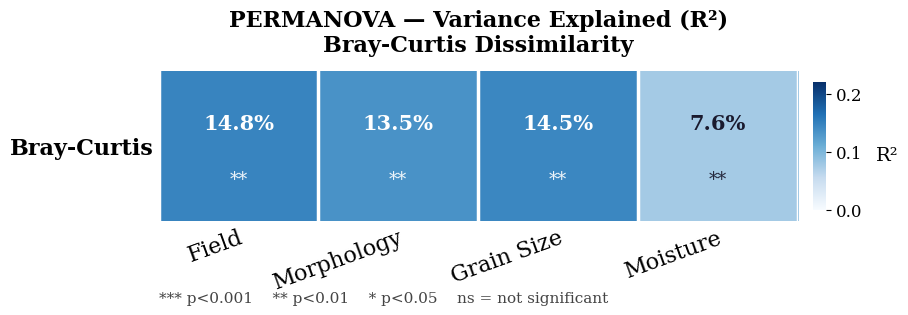

In [40]:
%matplotlib inline
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ============================
# HEATMAP — Bray-Curtis only
# one row, four variables
# ============================
VAR_ORDER  = ["Field", "Morphology", "GrainSize", "Moisture"]
VAR_LABELS = ["Field", "Morphology", "Grain Size", "Moisture"]

r2_mat = np.zeros((1, 4))
p_mat  = np.ones((1, 4))
dp_mat = np.full((1, 4), np.nan)

for vi, var in enumerate(VAR_ORDER):
    row = res_df[res_df["Variable"] == var]
    if len(row):
        r2_mat[0, vi] = row["R2"].values[0]
        p_mat[0,  vi] = row["p"].values[0]
        if "PERMDISP_p" in row.columns:
            dp_mat[0, vi] = row["PERMDISP_p"].values[0]

cmap = LinearSegmentedColormap.from_list(
    "r2map", ["#f7fbff","#c6dbef","#6baed6",
              "#2171b5","#08306b"])

fig_h, ax_h = plt.subplots(figsize=(11, 3))
fig_h.subplots_adjust(bottom=0.28, top=0.78,
                       left=0.18, right=0.88)
fig_h.patch.set_facecolor("white")

im = ax_h.imshow(r2_mat, cmap=cmap, aspect="auto",
                 vmin=0, vmax=max(0.22, r2_mat.max() + 0.02))

for vi in range(4):
    r2 = r2_mat[0, vi]
    p  = p_mat[0,  vi]
    tc = "white" if r2 > 0.13 else "#1a1a2e"

    # R² value
    ax_h.text(vi, -0.15, f"{r2*100:.1f}%",
              ha="center", va="center",
              fontsize=15, fontweight="bold", color=tc)

    # significance stars
    ax_h.text(vi, 0.22, sig_str(p),
              ha="center", va="center",
              fontsize=13, color=tc, alpha=0.90)

# grid lines
for x in np.arange(-0.5, 4, 1):
    ax_h.axvline(x, color="white", lw=2.5)

ax_h.set_xticks(range(4))
ax_h.set_xticklabels(VAR_LABELS, fontsize=16,
                     rotation=20, ha="right",
                     rotation_mode="anchor")
ax_h.set_yticks([0])
ax_h.set_yticklabels(["Bray-Curtis"], fontsize=16,
                     fontweight="bold")
ax_h.tick_params(length=0)
for sp in ax_h.spines.values():
    sp.set_visible(False)

ax_h.set_title(
    "PERMANOVA — Variance Explained (R²)\n"
    "Bray-Curtis Dissimilarity",
    fontsize=16, fontweight="bold", pad=14)

cb = fig_h.colorbar(im, ax=ax_h, shrink=0.85,
                     pad=0.02, aspect=10)
cb.set_label("R²", fontsize=14, labelpad=10,
             rotation=0, ha="left")
cb.ax.tick_params(labelsize=12)
cb.outline.set_visible(False)

fig_h.text(
    0.18, 0.01,
    "*** p<0.001    ** p<0.01    * p<0.05    ns = not significant",
    fontsize=11, color="#444444",
    transform=fig_h.transFigure)


display(fig_h)
plt.close(fig_h)


Moisture:

Dry samples  : 39
Moist samples: 13
Moist IDs    : ['ED.02B', 'ED.08A', 'ED.10A', 'MF.11A', 'MF.12A', 'MF.15A', 'MF.16A', 'MF.18B', 'MF.27B', 'MF.33A', 'MF.4B', 'MF.7B', 'MF.8B']
Saved → moisture_comparison.png

══════════ ALPHA DIVERSITY — DRY vs MOIST ══════════
  Shannon   : Dry=5.276±0.823  Moist=5.029±1.165  p=0.4724 ns
  Richness  : Dry=1566.051±303.145  Moist=1556.923±405.975  p=0.4531 ns
  Evenness  : Dry=0.717±0.100  Moist=0.684±0.143  p=0.5124 ns

══════════ TOP PHYLA MEAN ABUNDANCE ══════════
  Phylum                                 Dry %  Moist %     Diff
  actinomycetota                         29.76    29.70    -0.07
  pseudomonadota                         22.64    24.73    +2.09
  gemmatimonadota                        11.75    12.19    +0.44
  bacteroidota                            7.04    10.29    +3.25
  bacillota                               8.00     7.75    -0.25
  chloroflexota                           5.38     4.43    -0.96
  acidobacteriota                   

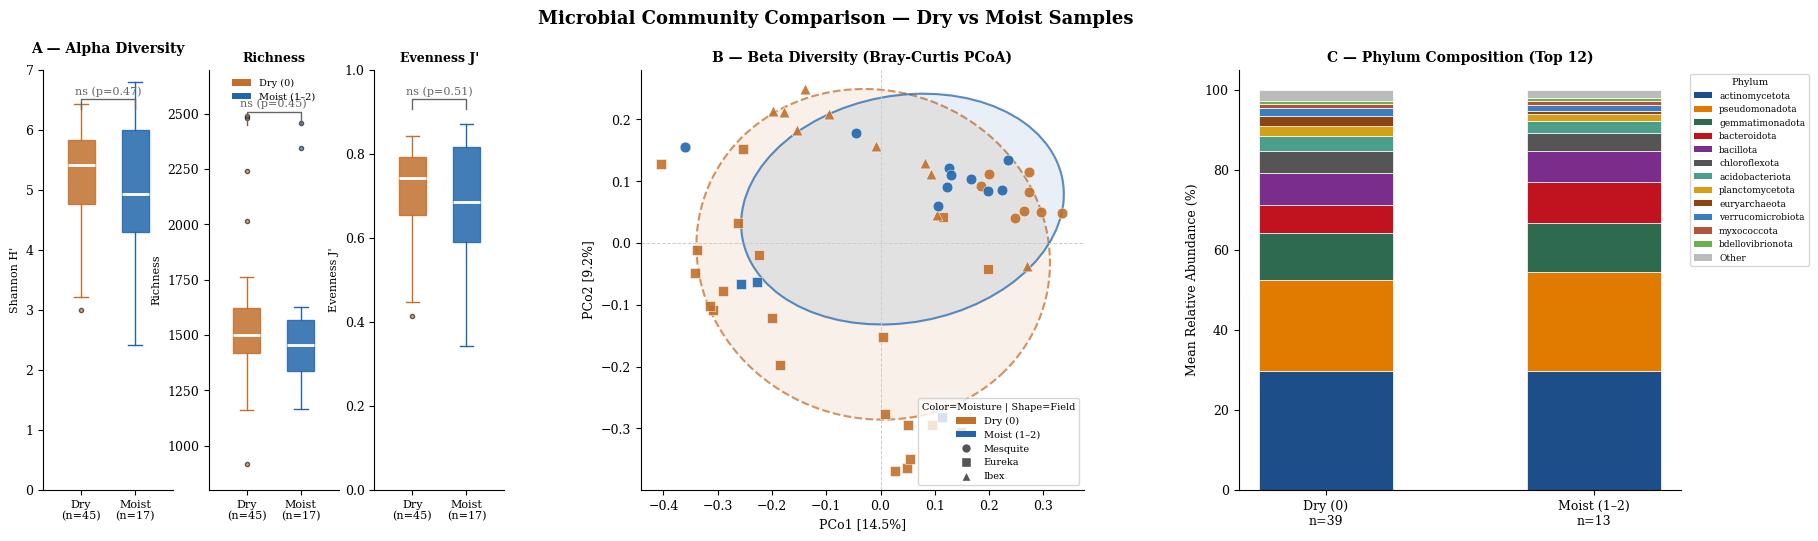

In [34]:
# =============================================================================
# MOISTURE COMPARISON — Dry (0) vs Moist (1+2)
# Panel A: Alpha diversity boxplots
# Panel B: PCoA (Bray-Curtis, relative abundance)
# Panel C: Phylum-level relative abundance stacked bar
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import pdist, squareform

# =============================================================================
# 1. PATHS
# =============================================================================
RAW_PATH  = "zotutab_decontam_Final.csv"
META_PATH = "PERM_metadata.csv"

# =============================================================================
# 2. LOAD DATA
# =============================================================================
raw = pd.read_csv(RAW_PATH, header=None)
df  = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

taxonomy_cols = df.columns[-7:].tolist()
sample_cols   = [c for c in df.columns[1:] if c not in taxonomy_cols]
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
df["Domain"]    = df["Domain"].str.strip().str.lower()
micro_df = df[df["Domain"].isin(["bacteria","archaea"])].copy()

meta = pd.read_csv(META_PATH).rename(columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

shared   = sorted(set(sample_cols) & set(meta.index))
meta_aln = meta.loc[shared].copy()
meta_aln["Moisture"] = pd.to_numeric(meta_aln["Moisture"], errors="coerce").fillna(0)

# Moisture groups: 0 = Dry, 1+2 = Moist
meta_aln["MoistureGroup"] = meta_aln["Moisture"].apply(
    lambda x: "Moist (1–2)" if x > 0 else "Dry (0)"
)

dry_samples   = meta_aln[meta_aln["MoistureGroup"] == "Dry (0)"].index.tolist()
moist_samples = meta_aln[meta_aln["MoistureGroup"] == "Moist (1–2)"].index.tolist()

print(f"Dry samples  : {len(dry_samples)}")
print(f"Moist samples: {len(moist_samples)}")
print(f"Moist IDs    : {moist_samples}")

# =============================================================================
# 3. ALPHA DIVERSITY
# =============================================================================
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0: return 0, 0, 0
    N = counts.sum(); p = counts / N
    shannon  = -np.sum(p * np.log(p))
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, richness, evenness

alpha_records = []
for s in shared:
    sh, ri, ev = compute_alpha(micro_df[s].values.astype(float))
    alpha_records.append({
        "Sample": s,
        "MoistureGroup": meta_aln.loc[s, "MoistureGroup"],
        "Field": meta_aln.loc[s, "Field"],
        "Shannon": sh, "Richness": ri, "Evenness": ev
    })
alpha_df = pd.DataFrame(alpha_records)

# =============================================================================
# 4. RELATIVE ABUNDANCE + BRAY-CURTIS
# =============================================================================
arr = micro_df[shared].values.T.astype(float)   # samples × ZOTUs
row_sums = arr.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
rel = arr / row_sums
bc  = squareform(pdist(rel, metric="braycurtis"))

# PCoA
def pcoa(D):
    D2 = D**2
    B  = -0.5*(D2 - D2.mean(1,keepdims=True) - D2.mean(0,keepdims=True) + D2.mean())
    ev, evec = np.linalg.eigh(B)
    idx = np.argsort(ev)[::-1]; ev = ev[idx]; evec = evec[:,idx]
    pos = ev > 0
    return evec[:,pos]*np.sqrt(ev[pos]), ev[pos]/ev[pos].sum()*100

coords, var_exp = pcoa(bc)

# =============================================================================
# 5. PHYLUM RELATIVE ABUNDANCE
# =============================================================================
phylum_df = micro_df.groupby("Phylum")[shared].sum()

# Relative abundance per sample
rel_phylum = phylum_df.div(phylum_df.sum(axis=0), axis=1) * 100

# Mean per moisture group
dry_mean   = rel_phylum[dry_samples].mean(axis=1)
moist_mean = rel_phylum[moist_samples].mean(axis=1)

# Keep top 12 phyla by overall mean abundance
top12 = (dry_mean + moist_mean).nlargest(12).index.tolist()
other_dry   = 100 - dry_mean[top12].sum()
other_moist = 100 - moist_mean[top12].sum()

# =============================================================================
# 6. COLORS
# =============================================================================
MOISTURE_COLORS = {"Dry (0)": "#c1702c", "Moist (1–2)": "#2166ac"}
FIELD_MARKERS   = {"Mesquite": "o", "Eureka": "s", "Ibex": "^", "Other": "D"}

# 12 distinct phylum colors
PHYLUM_COLORS = [
    "#1d4e89","#e07b00","#2d6a4f","#c1121f","#7b2d8b",
    "#555555","#4a9e8a","#d4a017","#8b4513","#3a7ebf",
    "#b5523a","#6ab04c"
]

# # =============================================================================
# # 7. FIGURE — 3 panels
# # =============================================================================
plt.rcParams.update({"font.family": "serif", "font.size": 9})

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35,
                        left=0.06, right=0.97, top=0.88, bottom=0.18)

ax_alpha = fig.add_subplot(gs[0])   # alpha diversity — 3 metrics
ax_pcoa  = fig.add_subplot(gs[1])   # PCoA
ax_phyla = fig.add_subplot(gs[2])   # phylum bar

fig.suptitle("Microbial Community Comparison — Dry vs Moist Samples",
             fontsize=13, fontweight="bold")

# ── PANEL A: Alpha Diversity — 3 sub-panels each with own y-axis ─────────────
metrics = [
    ("Shannon",  "Shannon H'",  (0, 7)),
    ("Richness", "Richness",    (800, 2700)),
    ("Evenness", "Evenness J'", (0, 1)),
]
groups  = ["Dry (0)", "Moist (1–2)"]

# subdivide ax_alpha into 3 mini axes
ax_alpha.set_visible(False)
pos = ax_alpha.get_position()
fig_w = pos.width / 3
axs_a = []
for mi in range(3):
    sub_ax = fig.add_axes([pos.x0 + mi * fig_w + mi * 0.01,
                           pos.y0, fig_w * 0.88, pos.height])
    axs_a.append(sub_ax)

for mi, (metric, label, ylim) in enumerate(metrics):
    ax = axs_a[mi]
    for gi, grp in enumerate(groups):
        vals = alpha_df[alpha_df["MoistureGroup"] == grp][metric].values
        bp = ax.boxplot(
            vals,
            positions=[gi],
            widths=0.5,
            patch_artist=True,
            medianprops=dict(color="white", linewidth=2),
            boxprops=dict(facecolor=MOISTURE_COLORS[grp],
                          color=MOISTURE_COLORS[grp], alpha=0.85),
            whiskerprops=dict(color=MOISTURE_COLORS[grp]),
            capprops=dict(color=MOISTURE_COLORS[grp]),
            flierprops=dict(marker="o",
                            markerfacecolor=MOISTURE_COLORS[grp],
                            markersize=3, linestyle="none", alpha=0.6)
        )

    # significance bracket
    dry_v   = alpha_df[alpha_df["MoistureGroup"]=="Dry (0)"][metric]
    moist_v = alpha_df[alpha_df["MoistureGroup"]=="Moist (1–2)"][metric]
    _, p    = mannwhitneyu(dry_v, moist_v, alternative="two-sided")
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else f"ns (p={p:.2f})"
    color_sig = "#c1121f" if p < 0.05 else "#666666"
    y_bracket = ylim[1] * 0.93
    ax.plot([0, 0, 1, 1], [y_bracket*0.975, y_bracket, y_bracket, y_bracket*0.975],
            color=color_sig, linewidth=1)
    ax.text(0.5, y_bracket * 1.005, sig, ha="center", va="bottom",
            fontsize=8, color=color_sig)

    ax.set_ylim(ylim)
    ax.set_xlim(-0.7, 1.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Dry\n(n=45)", "Moist\n(n=17)"], fontsize=8)
    ax.set_ylabel(label, fontsize=8)
    ax.set_title(label, fontsize=9, fontweight="bold")
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    if mi == 0:
        ax.set_title("A — Alpha Diversity", fontsize=10, fontweight="bold", pad=12)

# shared legend on first sub-axis
handles_a = [mpatches.Patch(facecolor=MOISTURE_COLORS[g], label=g) for g in groups]
axs_a[1].legend(handles=handles_a, fontsize=7, loc="upper center",
                bbox_to_anchor=(0.5, 1.0), frameon=False)

# ── PANEL B: PCoA colored by moisture group, shaped by field ─────────────────
groups_list = [meta_aln.loc[s, "MoistureGroup"] for s in shared]
fields_list = [meta_aln.loc[s, "Field"] for s in shared]

for i in range(len(shared)):
    color  = MOISTURE_COLORS.get(groups_list[i], "gray")
    marker = FIELD_MARKERS.get(fields_list[i], "o")
    ax_pcoa.scatter(coords[i,0], coords[i,1],
                    color=color, marker=marker, s=60,
                    edgecolors="white", linewidths=0.4,
                    alpha=0.90, zorder=3)

# Per-field confidence ellipses, colored by dominant moisture of that field
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, color, n_std=1.5, ls="--"):
    if len(x) < 3: return
    cov = np.cov(x, y)
    if cov[0,0] == 0 or cov[1,1] == 0: return
    pearson = np.clip(cov[0,1] / np.sqrt(cov[0,0] * cov[1,1]), -1, 1)
    rx, ry  = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0,0), width=rx*2, height=ry*2,
                      facecolor=color, edgecolor=color,
                      linewidth=1.5, linestyle=ls, alpha=0.10)
    ellipse2 = Ellipse((0,0), width=rx*2, height=ry*2,
                       facecolor="none", edgecolor=color,
                       linewidth=1.5, linestyle=ls, alpha=0.7)
    scale_x = np.sqrt(cov[0,0]) * n_std
    scale_y = np.sqrt(cov[1,1]) * n_std
    t = (transforms.Affine2D()
         .rotate_deg(45).scale(scale_x, scale_y)
         .translate(np.mean(x), np.mean(y)))
    for e in [ellipse, ellipse2]:
        e.set_transform(t + ax_pcoa.transData)
        ax_pcoa.add_patch(e)

# draw per-moisture ellipse, but split by field to show structure
for grp, color in MOISTURE_COLORS.items():
    idx = [i for i,g in enumerate(groups_list) if g == grp]
    if len(idx) >= 3:
        confidence_ellipse(coords[idx,0], coords[idx,1], ax_pcoa, color,
                           ls="--" if grp=="Dry (0)" else "-")

ax_pcoa.axhline(0, color="#cccccc", lw=0.7, ls="--", zorder=1)
ax_pcoa.axvline(0, color="#cccccc", lw=0.7, ls="--", zorder=1)
ax_pcoa.set_xlabel(f"PCo1 [{var_exp[0]:.1f}%]", fontsize=9)
ax_pcoa.set_ylabel(f"PCo2 [{var_exp[1]:.1f}%]", fontsize=9)
ax_pcoa.set_title("B — Beta Diversity (Bray-Curtis PCoA)", fontsize=10, fontweight="bold")
for sp in ["top","right"]: ax_pcoa.spines[sp].set_visible(False)

# legend: moisture color + field marker
moisture_handles = [mpatches.Patch(facecolor=c, label=g)
                    for g, c in MOISTURE_COLORS.items()]
field_handles    = [plt.Line2D([0],[0], marker=m, color="w",
                               markerfacecolor="#555555",
                               markeredgecolor="white",
                               markersize=7, label=f)
                    for f, m in FIELD_MARKERS.items() if f != "Other"]
ax_pcoa.legend(handles=moisture_handles + field_handles,
               fontsize=7, loc="lower right",
               title="Color=Moisture | Shape=Field", title_fontsize=7)

# ── PANEL C: Phylum stacked bar — dry vs moist ───────────────────────────────
bar_data = pd.DataFrame({
    "Dry (0)":     [dry_mean[p] for p in top12] + [other_dry],
    "Moist (1–2)": [moist_mean[p] for p in top12] + [other_moist],
}, index=top12 + ["Other"])

bar_x = [0, 1]
bottoms = {"Dry (0)": 0, "Moist (1–2)": 0}

for pi, phylum in enumerate(bar_data.index):
    color = PHYLUM_COLORS[pi] if pi < 12 else "#bbbbbb"
    for gi, grp in enumerate(["Dry (0)", "Moist (1–2)"]):
        val = bar_data.loc[phylum, grp]
        ax_phyla.bar(gi, val, bottom=bottoms[grp],
                     color=color, width=0.5,
                     edgecolor="white", linewidth=0.5)
        bottoms[grp] += val

ax_phyla.set_xticks([0, 1])
ax_phyla.set_xticklabels(["Dry (0)\nn=" + str(len(dry_samples)),
                           "Moist (1–2)\nn=" + str(len(moist_samples))],
                          fontsize=9)
ax_phyla.set_ylabel("Mean Relative Abundance (%)", fontsize=9)
ax_phyla.set_title("C — Phylum Composition (Top 12)", fontsize=10, fontweight="bold")
ax_phyla.set_ylim(0, 105)
for sp in ["top","right"]: ax_phyla.spines[sp].set_visible(False)

# phylum legend
phylum_handles = [mpatches.Patch(facecolor=PHYLUM_COLORS[i], label=p)
                  for i, p in enumerate(top12)]
phylum_handles.append(mpatches.Patch(facecolor="#bbbbbb", label="Other"))
ax_phyla.legend(handles=phylum_handles, fontsize=6.5,
                loc="upper left", bbox_to_anchor=(1.01, 1.0),
                title="Phylum", title_fontsize=7, frameon=True)


#plt.show()

# =============================================================================
# 8. PRINT STATS SUMMARY
# =============================================================================
print("\n══════════ ALPHA DIVERSITY — DRY vs MOIST ══════════")
for metric in ["Shannon","Richness","Evenness"]:
    dry_v   = alpha_df[alpha_df["MoistureGroup"]=="Dry (0)"][metric]
    moist_v = alpha_df[alpha_df["MoistureGroup"]=="Moist (1–2)"][metric]
    _, p    = mannwhitneyu(dry_v, moist_v, alternative="two-sided")
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    print(f"  {metric:10s}: Dry={dry_v.mean():.3f}±{dry_v.std():.3f}  "
          f"Moist={moist_v.mean():.3f}±{moist_v.std():.3f}  "
          f"p={p:.4f} {sig}")

print("\n══════════ TOP PHYLA MEAN ABUNDANCE ══════════")
print(f"  {'Phylum':35s} {'Dry %':>8} {'Moist %':>8} {'Diff':>8}")
for p in top12:
    d = dry_mean[p]; m = moist_mean[p]
    print(f"  {p:35s} {d:8.2f} {m:8.2f} {m-d:+8.2f}")

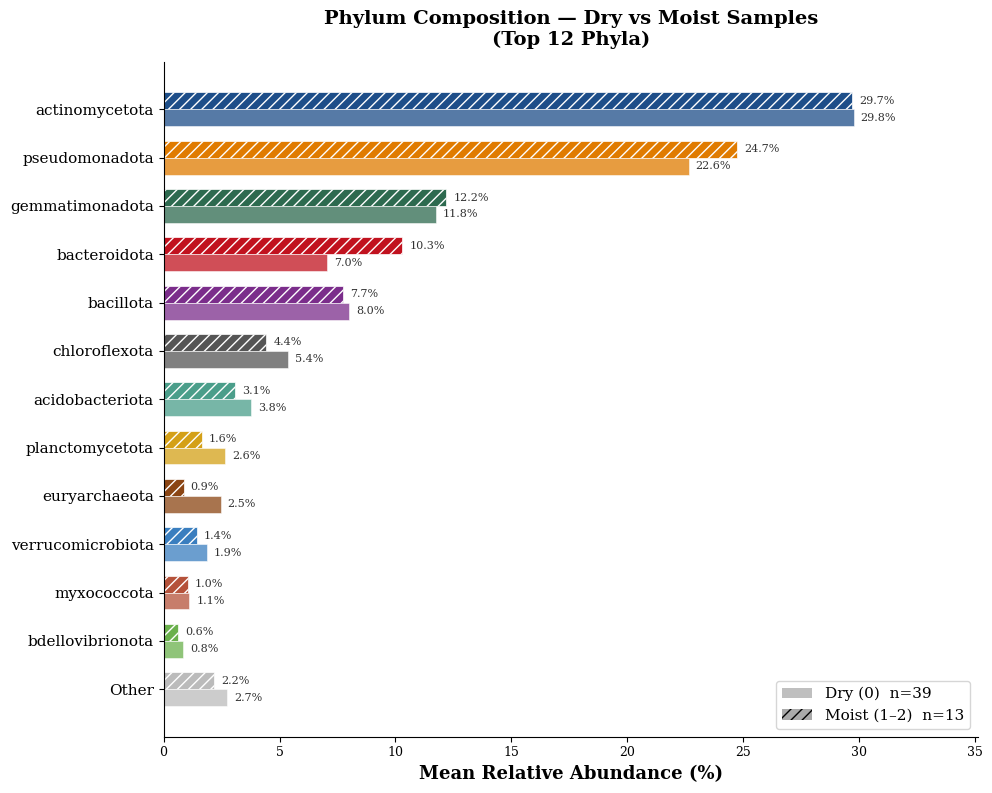

In [35]:
%matplotlib inline
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── assumes bar_data, top12, PHYLUM_COLORS, dry_samples, moist_samples
#    are already in memory from the cell above ─────────────────────────────────

phyla    = top12 + ["Other"]
n_phyla  = len(phyla)
y        = np.arange(n_phyla)
bar_h    = 0.35

dry_vals   = [bar_data.loc[p, "Dry (0)"]     for p in phyla]
moist_vals = [bar_data.loc[p, "Moist (1–2)"] for p in phyla]
colors     = [PHYLUM_COLORS[i] if i < 12 else "#bbbbbb" for i in range(n_phyla)]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")

# moist bars — bottom of each pair, hatched
bars_moist = ax.barh(y - bar_h/2, moist_vals,
                     height=bar_h, color=colors,
                     edgecolor="white", linewidth=0.5,
                     alpha=1.0, hatch="///", label="Moist (1–2)")
# dry bars — top of each pair
bars_dry = ax.barh(y + bar_h/2, dry_vals,
                   height=bar_h, color=colors,
                   edgecolor="white", linewidth=0.5,
                   alpha=0.75, label="Dry (0)")



# value labels
for i, (dv, mv) in enumerate(zip(dry_vals, moist_vals)):
    if dv > 0.5:
        ax.text(dv + 0.3, i + bar_h/2, f"{dv:.1f}%",
                va="center", fontsize=8, color="#333333")
    if mv > 0.5:
        ax.text(mv + 0.3, i - bar_h/2, f"{mv:.1f}%",
                va="center", fontsize=8, color="#333333")

ax.set_yticks(y)
ax.set_yticklabels(phyla, fontsize=11)
ax.set_xlabel("Mean Relative Abundance (%)", fontsize=13, fontweight="bold")
ax.set_title("Phylum Composition — Dry vs Moist Samples\n(Top 12 Phyla)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlim(0, max(max(dry_vals), max(moist_vals)) * 1.18)
ax.invert_yaxis()  # highest abundance at top
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)

# group legend (dry vs moist)
legend_handles = [
    mpatches.Patch(facecolor="#aaaaaa", alpha=0.75,
                   label=f"Dry (0)  n={len(dry_samples)}"),
    mpatches.Patch(facecolor="#aaaaaa", hatch="///",
                   label=f"Moist (1–2)  n={len(moist_samples)}"),
]
ax.legend(handles=legend_handles, fontsize=11,
          loc="lower right", frameon=True, edgecolor="#cccccc")

plt.tight_layout()
display(fig)
plt.close(fig)